**Review**

Inconsistencies:

1. Add **evaluation megtric from Kaggle**: https://www.kaggle.com/competitions/ts-forecasting/overview

2.  **Leakage**: in load_feature_set, the scaler is fit globally across all training groups:

pythonscaler = RobustScaler().fit(all_train)

global scaler's median/IQR is computed from all series pooled together, which leaks distribution information across groups AND it is bad for sequential requirement

3.  The target column y_target is used as the first input feature

pythonmodel_cols = [TARGET_COL] + feature_cols   # y_target is channel 0

At position i in the sequence, you include y_target at time steps i through i+SEQ_LEN-1, and predict y_target at step i+SEQ_LEN. This is fine during training since those past targets are known. But at test time, the competition's test rows are future observations — you don't have the historical y_target values for the test group unless you reconstruct them from the training tail. **This is exactly what group_tails.pkl is meant to solve, but Block B/C/D never update or save it for the new feature sets.**


# CNN Experiments — Blocks B, C, D

This notebook assumes Block A (baseline CNN) has already been run and the following files have been saved:
- `best_cnn.pt` -- best model weights
- `scaler.pkl` -- fitted scaler
- `group_tails.pkl` -- group tails for inference
- `X_train, y_train, X_val, y_val` -- training and validation arrays in memory

Each block changes **one variable** at a time; everything else is kept fixed.

## Table of Contents
- [0 - Imports and Shared Utilities](#0)
- [1 - Block B: Feature Sets](#1)
- [2 - Block C: Training Hyperparameters](#2)
    - [2.1 - C1: Optimizer](#2-1)
    - [2.2 - C2: Learning Rate](#2-2)
    - [2.3 - C3: Batch Size](#2-3)
    - [2.4 - C4: LR Scheduler](#2-4)
    - [2.5 - C5: Early Stopping Patience](#2-5)
- [3 - Block D: Architecture Depth and Regularization](#3)
    - [3.1 - D1: Number of Layers](#3-1)
    - [3.2 - D2: Number of Filters](#3-2)
    - [3.3 - D3: Dropout](#3-3)
    - [3.4 - D4: Batch Normalization](#3-4)
- [4 - Summary Table](#4)

<a name="0"></a>
## 0 - Imports and Shared Utilities

In [1]:
# В Jupyter / VS Code / Cursor: встраивать графики в вывод ячейки (иначе иногда «пустой» рисунок)
%matplotlib inline

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import copy, time, warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: " + str(DEVICE))


Device: cuda


In [2]:
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Device: " + str(DEVICE))


Device: cuda


In [3]:
# Shared constants (must match Block A)
INPUT_SIZE  = 30   # 1 target + 29 features
SEQ_LEN     = 20
EPOCHS      = 40   # max; early stopping will cut it short
PATIENCE    = 10

# Block A best config — carried forward as fixed baseline for B, C, D
BEST_A_NUM_FILTERS  = 64
BEST_A_KERNEL_SIZE  = 3
BEST_A_NUM_LAYERS   = 3
BEST_A_DROPOUT      = 0.4
BEST_A_BATCH_SIZE   = 256
BEST_A_LR           = 1e-4
BEST_A_OPTIMIZER    = "Adam"
BEST_A_SCHEDULER    = "ReduceOnPlateau"
BEST_A_FEATURE_SET  = "set_global_uncorr"  # placeholder; Block B picks the winner


In [4]:
# Experiment log — every run appends one row, never overwrite
results_log = []   # list of dicts → DataFrame at the end

def log_run(run_id, block, model_name, feature_set, optimizer_name,
            lr, batch_size, epochs_run, val_mae, val_rmse, extra=""):
    results_log.append({
        "run_id":      run_id,
        "block":       block,
        "model":       model_name,
        "feature_set": feature_set,
        "optimizer":   optimizer_name,
        "lr":          lr,
        "batch_size":  batch_size,
        "epochs_run":  epochs_run,
        "val_mae":     round(val_mae, 5),
        "val_rmse":    round(val_rmse, 5),
        "extra":       extra,
    })
    print(f"[{run_id}] MAE={val_mae:.5f}  RMSE={val_rmse:.5f}  epochs={epochs_run}")

def show_log():
    df = pd.DataFrame(results_log)
    display(df.sort_values(["block", "val_mae"]).reset_index(drop=True))
    return df


In [5]:
# Model definition (same as Block A)
class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dropout):
        """
        Single residual block with two Conv1d layers and BatchNorm.

        Arguments:
        channels -- number of input and output channels, integer
        kernel_size -- convolutional kernel size, integer
        dropout -- dropout probability, scalar
        """
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class CNNForecaster(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, num_filters=64,
                 kernel_size=3, num_layers=3, dropout=0.2):
        """
        1D CNN forecaster with residual blocks and global average pooling.

        Arguments:
        input_size -- number of input channels (features), integer
        num_filters -- number of convolutional filters per layer, integer
        kernel_size -- convolutional kernel size, integer
        num_layers -- number of residual blocks, integer
        dropout -- dropout probability, scalar
        """
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(input_size, num_filters, kernel_size=1),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(*[
            ResidualBlock(num_filters, kernel_size, dropout)
            for _ in range(num_layers)
        ])
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(num_filters, num_filters // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(num_filters // 2, 1),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.blocks(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x).squeeze(-1)


class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


In [6]:
# Generic train + eval function
def make_optimizer(name, params, lr, weight_decay=1e-5):
    """
    Instantiate an optimizer by name.

    Arguments:
    name -- optimizer name, string ("Adam", "SGD", "RMSProp")
    params -- model parameters to optimize
    lr -- learning rate, scalar
    weight_decay -- L2 regularization coefficient, scalar

    Returns:
    optimizer -- torch.optim optimizer instance
    """
    if name == "Adam":     return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "SGD":      return torch.optim.SGD(params,  lr=lr, weight_decay=weight_decay, momentum=0.9)
    if name == "RMSProp":  return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")


def make_scheduler(name, optimizer):
    """
    Instantiate a learning rate scheduler by name.

    Arguments:
    name -- scheduler name, string ("ReduceOnPlateau", "StepLR", "CosineAnnealing", "None")
    optimizer -- optimizer instance to attach the scheduler to

    Returns:
    scheduler -- torch.optim.lr_scheduler instance, or None
    """
    if name == "ReduceOnPlateau":   return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)
    if name == "StepLR":            return torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    if name == "CosineAnnealing":   return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    if name == "None":              return None
    raise ValueError(f"Unknown scheduler: {name}")


def train_and_eval(model, train_loader, val_loader,
                   optimizer_name="Adam", lr=1e-3,
                   scheduler_name="ReduceOnPlateau",
                   patience=PATIENCE, epochs=EPOCHS,
                   save_path="best_exp.pt"):
    """
    Train the model and evaluate on validation set after each epoch.

    Arguments:
    model -- CNNForecaster instance to train
    train_loader -- DataLoader for the training set
    val_loader -- DataLoader for the validation set
    optimizer_name -- name of the optimizer to use, string ("Adam", "SGD", "RMSProp")
    lr -- learning rate, scalar
    scheduler_name -- name of the LR scheduler, string
    patience -- early stopping patience, integer
    epochs -- maximum number of training epochs, integer
    save_path -- file path to save the best model weights, string

    Returns:
    best_mae -- best validation MAE achieved, scalar
    best_rmse -- best validation RMSE achieved, scalar
    epochs_run -- number of epochs completed, integer
    history -- dictionary containing lists of train loss, val loss, and val MAE
    """
    if len(train_loader) == 0:
        raise RuntimeError("train_loader has 0 batches — no training rows. Check load_feature_set / N_SAMPLE_GROUPS.")
    if len(val_loader) == 0:
        raise RuntimeError("val_loader has 0 batches — cannot validate.")

    criterion = nn.HuberLoss(delta=1.0)
    optimizer = make_optimizer(optimizer_name, model.parameters(), lr)
    scheduler = make_scheduler(scheduler_name, optimizer)

    best_val_loss = float("inf")
    best_mae = best_rmse = float("inf")
    patience_ctr = 0
    history = {"train": [], "val": [], "mae": []}
    epoch_run = 0

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss_total, n = 0.0, 0
        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(DEVICE), Y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), Y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss_total += loss.item() * len(Y_batch); n += len(Y_batch)
        train_loss = train_loss_total / n

        # Val
        model.eval()
        val_loss_total, n = 0.0, 0
        predictions_list, targets_list = [], []
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch, Y_batch = X_batch.to(DEVICE), Y_batch.to(DEVICE)
                p = model(X_batch)
                val_loss_total += criterion(p, Y_batch).item() * len(Y_batch); n += len(Y_batch)
                predictions_list.append(p.cpu()); targets_list.append(Y_batch.cpu())
        val_loss = val_loss_total / n
        predictions = torch.cat(predictions_list); targets = torch.cat(targets_list)
        val_mae  = torch.mean(torch.abs(predictions - targets)).item()
        val_rmse = torch.sqrt(torch.mean((predictions - targets) ** 2)).item()

        # Scheduler step
        if scheduler is not None:
            if scheduler_name == "ReduceOnPlateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["mae"].append(val_mae)
        epoch_run = epoch

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_mae  = val_mae
            best_rmse = val_rmse
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_ctr += 1

        if epoch % 5 == 0 or patience_ctr >= patience:
            print(f"  ep {epoch:3d} | train={train_loss:.5f} val={val_loss:.5f} MAE={val_mae:.5f}")

        if patience_ctr >= patience:
            print(f"  → Early stop at epoch {epoch}")
            break

    return best_mae, best_rmse, epoch_run, history


def plot_history(history, title):
    n = len(history.get("train", []))
    if n == 0:
        print(
            f"[plot_history] Нет точек для «{title}»: история обучения пуста. "
            "Обычно это значит, что до train_and_eval не дошло ни одной эпохи "
            "(ошибка выше, EPOCHS=0, или ячейка с графиком выполнена без обучения / не тем hist)."
        )
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].plot(history["train"], label="train"); axes[0].plot(history["val"], label="val")
    axes[0].set_title(f"{title} — Huber loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history["mae"], color="orange", label="val MAE")
    axes[1].set_title(f"{title} — Val MAE"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


<a name="1"></a>
## 1 - Config: Horizons & Data Paths

Each horizon (1, 3, 10, 25) has its own dedicated feature set. Blocks C and D
are run independently for every horizon; the best config per horizon is used for
final training and test inference.

| Horizon | Feature set file |
|---------|-----------------|
| 1  | `data/set_h1_uncorr.parquet`  |
| 3  | `data/set_h3_uncorr.parquet`  |
| 10 | `data/set_h10_uncorr.parquet` |
| 25 | `data/set_h25_uncorr.parquet` |


In [7]:
# ── Horizon → preprocessed data folder mapping ───────────────────────────────
# Each folder contains: train.parquet, valid.parquet, test.parquet
# train/valid have: id, code, sub_code, sub_category, horizon, ts_index,
#                   weight, split, y_target, feature_*
# test has the same columns minus y_target, weight, split
HORIZONS = {
    3:  "/content/set_h3_uncorr",
    1:  "/content/set_h1_uncorr",
    10: "/content/set_h10_uncorr",
    25: "/content/set_h25_uncorr",
}

# Original test.parquet — used ONLY to recover the official submission row order
TEST_PATH_ORIG = "/content/data/test.parquet"

ID_COL     = "id"
GROUP_KEYS = ["code", "sub_code", "sub_category", "horizon"]
TARGET_COL = "y_target"
TIME_COL   = "ts_index"
N_SAMPLE_GROUPS = 500


In [8]:
def load_feature_set_for_horizon(hz, folder, n_sample=N_SAMPLE_GROUPS, seq_len=SEQ_LEN):
    """
    Load preprocessed train.parquet + valid.parquet from `folder`.
    Fits RobustScaler on train. Returns sliding-window sequences + scaler.

    Parameters
    ----------
    hz       : int   horizon value (used only for logging)
    folder   : str   path to folder containing train.parquet / valid.parquet
    n_sample : int   max number of groups to use (for experiment speed);
                     pass a large number for final training
    seq_len  : int   sliding-window length

    Returns
    -------
    X_tr, y_tr, X_va, y_va : np.float32 arrays
    input_size              : int  (1 + n_features)
    scaler                  : fitted RobustScaler  (fit on train groups only)
    feature_cols            : list[str]  feature column names
    """
    from sklearn.preprocessing import RobustScaler
    import gc

    _skip = {"id", "code", "sub_code", "sub_category", "horizon",
             "ts_index", "weight", "split", "y_target"}

    df_tr = pd.read_parquet(f"{folder}/train.parquet")
    df_va = pd.read_parquet(f"{folder}/valid.parquet")

    feature_cols = [c for c in df_tr.columns if c not in _skip]
    model_cols   = [TARGET_COL] + feature_cols
    input_size   = 1 + len(feature_cols)
    print(f"  h{hz} | train={len(df_tr):,} val={len(df_va):,} | {input_size} channels ({len(feature_cols)} features)")

    # Sample a subset of groups for experiment speed
    unique_keys  = df_tr[GROUP_KEYS].drop_duplicates()
    sampled_keys = unique_keys.sample(n=min(n_sample, len(unique_keys)), random_state=SEED)
    df_tr = df_tr.merge(sampled_keys, on=GROUP_KEYS, how="inner")
    df_va = df_va.merge(sampled_keys, on=GROUP_KEYS, how="inner")

    def _build_groups(df):
        groups = {}
        for name, gdf in df.groupby(GROUP_KEYS, sort=False):
            gdf = gdf.sort_values(TIME_COL)
            gdf[model_cols] = gdf[model_cols].ffill().bfill().fillna(0.0)
            vals = gdf[model_cols].values.astype(np.float32)
            if len(vals) >= seq_len + 1:
                groups[name] = vals
        return groups

    group_tr = _build_groups(df_tr)
    group_va = _build_groups(df_va)
    del df_tr, df_va; gc.collect()

    # Fit scaler on training data only
    all_train = np.concatenate(list(group_tr.values()))
    scaler    = RobustScaler().fit(all_train)
    del all_train; gc.collect()

    def _make_seqs(groups):
        Xs, ys = [], []
        for vals in groups.values():
            s = scaler.transform(vals).astype(np.float32)
            T, F = s.shape
            N    = T - seq_len
            if N <= 0:
                continue
            X = np.empty((N, F, seq_len), dtype=np.float32)
            y = np.empty(N,              dtype=np.float32)
            for i in range(N):
                X[i] = s[i:i+seq_len].T
                y[i] = s[i+seq_len, 0]
            Xs.append(X); ys.append(y)
        return np.concatenate(Xs), np.concatenate(ys)

    X_tr, y_tr = _make_seqs(group_tr)
    X_va, y_va = _make_seqs(group_va)
    print(f"  Train seqs: {len(X_tr):,} | Val seqs: {len(X_va):,}")
    return X_tr, y_tr, X_va, y_va, input_size, scaler, feature_cols


In [9]:
def make_loaders(X_tr, y_tr, X_va, y_va, batch_size):
    """Build train and validation DataLoaders."""
    tr = DataLoader(TSDataset(X_tr, y_tr), batch_size=batch_size,
                    shuffle=True, num_workers=0)
    va = DataLoader(TSDataset(X_va, y_va), batch_size=batch_size * 2,
                    num_workers=0)
    return tr, va


<a name="2"></a>
## 2 - Hyperparameter & Architecture Search (per horizon)

For each horizon the following experiments are run sequentially (greedy one-at-a-time):

**Block C — Training hyperparameters:**

| Step | Variable | Candidates |
|------|----------|-----------|
| C1 | Optimizer | Adam / SGD / RMSProp |
| C2 | Learning rate | 1e-4 / 1e-3 / 5e-3 |
| C3 | Batch size | 32 / 64 / 128 |
| C4 | LR Scheduler | ReduceOnPlateau / CosineAnnealing / None |
| C5 | Patience | 4 / 6 / 10 |

**Block D — Architecture:**

| Step | Variable | Candidates |
|------|----------|-----------|
| D1 | Num layers | 1 / 2 / 3 |
| D2 | Num filters | 64 / 128 / 256 |
| D3 | Dropout | 0.0 / 0.2 / 0.5 |


In [10]:
def run_experiments_for_horizon(hz, fs_path):
    """
    Run full C1-C5 + D1-D3 hyperparameter search for one horizon.
    Logs every candidate to results_log.
    Returns best_cfg (dict), scaler, feature_cols.
    """
    import gc
    hz_label = f"h{hz}"
    print(f"\n{'='*60}")
    print(f"  HORIZON {hz}  |  {fs_path}")
    print(f"{'='*60}")

    X_tr, y_tr, X_va, y_va, input_size, scaler, feature_cols = \
        load_feature_set_for_horizon(hz, fs_path)

    # Running best (updated greedily)
    best = {
        "optimizer":   BEST_A_OPTIMIZER,
        "lr":          BEST_A_LR,
        "batch_size":  BEST_A_BATCH_SIZE,
        "scheduler":   BEST_A_SCHEDULER,
        "patience":    PATIENCE,
        "num_layers":  BEST_A_NUM_LAYERS,
        "num_filters": BEST_A_NUM_FILTERS,
        "dropout":     BEST_A_DROPOUT,
    }

    def fresh_model(num_filters=None, num_layers=None, dropout=None):
        torch.manual_seed(SEED)
        return CNNForecaster(
            input_size  = input_size,
            num_filters = num_filters  if num_filters  is not None else best["num_filters"],
            kernel_size = BEST_A_KERNEL_SIZE,
            num_layers  = num_layers   if num_layers   is not None else best["num_layers"],
            dropout     = dropout      if dropout       is not None else best["dropout"],
        ).to(DEVICE)

    def run_trial(run_id, model, opt, lr, bs, sched, pat, extra):
        tr_l, va_l = make_loaders(X_tr, y_tr, X_va, y_va, bs)
        mae, rmse, ep, hist = train_and_eval(
            model, tr_l, va_l,
            optimizer_name=opt, lr=lr, scheduler_name=sched, patience=pat,
            save_path=f"_tmp_{hz}.pt",
        )
        log_run(run_id, hz_label, "CNN", f"set_h{hz}_uncorr",
                opt, lr, bs, ep, mae, rmse, extra=extra)
        plot_history(hist, run_id)
        return mae

    # ── C1: Optimizer ─────────────────────────────────────────────────────────
    print(f"\n--- C1: Optimizer ---")
    c1 = {}
    for opt in ["Adam", "SGD", "RMSProp"]:
        print(f"  {opt} ...", end=" ", flush=True)
        c1[opt] = run_trial(f"{hz_label}-C1-{opt}", fresh_model(), opt,
                            best["lr"], best["batch_size"], best["scheduler"],
                            best["patience"], "C1-optimizer")
        print(f"MAE={c1[opt]:.5f}")
    best["optimizer"] = min(c1, key=c1.get)
    print(f"  -> best: {best['optimizer']}")

    # ── C2: Learning rate ─────────────────────────────────────────────────────
    print(f"\n--- C2: Learning rate ---")
    c2 = {}
    for lr in [1e-4, 1e-3, 5e-3]:
        print(f"  lr={lr} ...", end=" ", flush=True)
        c2[lr] = run_trial(f"{hz_label}-C2-{lr}", fresh_model(), best["optimizer"],
                           lr, best["batch_size"], best["scheduler"],
                           best["patience"], "C2-lr")
        print(f"MAE={c2[lr]:.5f}")
    best["lr"] = min(c2, key=c2.get)
    print(f"  -> best: {best['lr']}")

    # ── C3: Batch size ────────────────────────────────────────────────────────
    print(f"\n--- C3: Batch size ---")
    c3 = {}
    for bs in [32, 64, 128]:
        print(f"  bs={bs} ...", end=" ", flush=True)
        c3[bs] = run_trial(f"{hz_label}-C3-{bs}", fresh_model(), best["optimizer"],
                           best["lr"], bs, best["scheduler"],
                           best["patience"], "C3-batch")
        print(f"MAE={c3[bs]:.5f}")
    best["batch_size"] = min(c3, key=c3.get)
    print(f"  -> best: {best['batch_size']}")

    # ── C4: LR Scheduler ──────────────────────────────────────────────────────
    print(f"\n--- C4: Scheduler ---")
    c4 = {}
    for sched in ["ReduceOnPlateau", "CosineAnnealing", "None"]:
        print(f"  {sched} ...", end=" ", flush=True)
        c4[sched] = run_trial(f"{hz_label}-C4-{sched}", fresh_model(), best["optimizer"],
                              best["lr"], best["batch_size"], sched,
                              best["patience"], "C4-scheduler")
        print(f"MAE={c4[sched]:.5f}")
    best["scheduler"] = min(c4, key=c4.get)
    print(f"  -> best: {best['scheduler']}")

    # ── C5: Patience ──────────────────────────────────────────────────────────
    print(f"\n--- C5: Patience ---")
    c5 = {}
    for pat in [4, 6, 10]:
        print(f"  patience={pat} ...", end=" ", flush=True)
        c5[pat] = run_trial(f"{hz_label}-C5-{pat}", fresh_model(), best["optimizer"],
                            best["lr"], best["batch_size"], best["scheduler"],
                            pat, "C5-patience")
        print(f"MAE={c5[pat]:.5f}")
    best["patience"] = min(c5, key=c5.get)
    print(f"  -> best: {best['patience']}")

    # ── D1: Num layers ────────────────────────────────────────────────────────
    print(f"\n--- D1: Num layers ---")
    d1 = {}
    for nl in [1, 2, 3]:
        print(f"  layers={nl} ...", end=" ", flush=True)
        d1[nl] = run_trial(f"{hz_label}-D1-{nl}", fresh_model(num_layers=nl),
                           best["optimizer"], best["lr"], best["batch_size"],
                           best["scheduler"], best["patience"], f"D1-layers={nl}")
        print(f"MAE={d1[nl]:.5f}")
    best["num_layers"] = min(d1, key=d1.get)
    print(f"  -> best: {best['num_layers']}")

    # ── D2: Num filters ───────────────────────────────────────────────────────
    print(f"\n--- D2: Num filters ---")
    d2 = {}
    for nf in [64, 128, 256]:
        print(f"  filters={nf} ...", end=" ", flush=True)
        d2[nf] = run_trial(f"{hz_label}-D2-{nf}",
                           fresh_model(num_filters=nf, num_layers=best["num_layers"]),
                           best["optimizer"], best["lr"], best["batch_size"],
                           best["scheduler"], best["patience"], f"D2-filters={nf}")
        print(f"MAE={d2[nf]:.5f}")
    best["num_filters"] = min(d2, key=d2.get)
    print(f"  -> best: {best['num_filters']}")

    # ── D3: Dropout ───────────────────────────────────────────────────────────
    print(f"\n--- D3: Dropout ---")
    d3 = {}
    for drop in [0.0, 0.2, 0.5]:
        print(f"  dropout={drop} ...", end=" ", flush=True)
        d3[drop] = run_trial(f"{hz_label}-D3-{drop}",
                             fresh_model(num_layers=best["num_layers"],
                                         num_filters=best["num_filters"],
                                         dropout=drop),
                             best["optimizer"], best["lr"], best["batch_size"],
                             best["scheduler"], best["patience"], f"D3-dropout={drop}")
        print(f"MAE={d3[drop]:.5f}")
    best["dropout"] = min(d3, key=d3.get)
    print(f"  -> best: {best['dropout']}")

    print(f"\n  Best config for horizon {hz}:")
    for k, v in best.items():
        print(f"    {k:15s}: {v}")
    gc.collect()
    return best, scaler, feature_cols



  HORIZON 3  |  /content/set_h3_uncorr
  h3 | train=1,108,291 val=277,525 | 13 channels (12 features)
  Train seqs: 64,589 | Val seqs: 1,755

--- C1: Optimizer ---
  Adam ...   ep   5 | train=26.48078 val=42.96814 MAE=43.22601
  ep  10 | train=25.91769 val=42.25049 MAE=42.52128
  ep  15 | train=25.03821 val=41.61266 MAE=41.90667
  ep  20 | train=24.06071 val=40.20359 MAE=40.48158
  ep  25 | train=23.15549 val=39.10503 MAE=39.35012
  ep  30 | train=22.31819 val=38.41312 MAE=38.66145
  ep  35 | train=21.56404 val=37.60141 MAE=37.84628
  ep  40 | train=21.25104 val=37.13368 MAE=37.38854
[h3-C1-Adam] MAE=37.38854  RMSE=145.83009  epochs=40


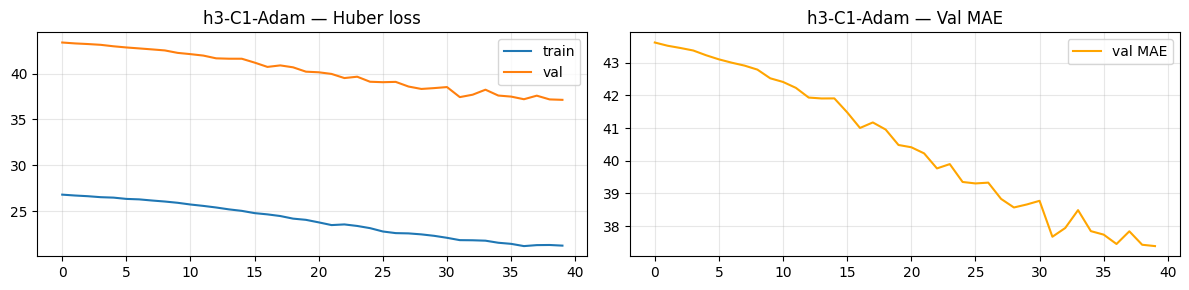

MAE=37.38854
  SGD ...   ep   5 | train=26.81734 val=43.44388 MAE=43.68504
  ep  10 | train=26.78313 val=43.40298 MAE=43.64639
  ep  15 | train=26.72753 val=43.35577 MAE=43.60069
  ep  20 | train=26.66854 val=43.27822 MAE=43.52390
  ep  25 | train=26.60282 val=43.20496 MAE=43.44892
  ep  30 | train=26.55446 val=43.15444 MAE=43.39576
  ep  35 | train=26.50661 val=43.06416 MAE=43.30373
  ep  40 | train=26.46417 val=43.00437 MAE=43.24271
[h3-C1-SGD] MAE=43.23083  RMSE=170.63652  epochs=40


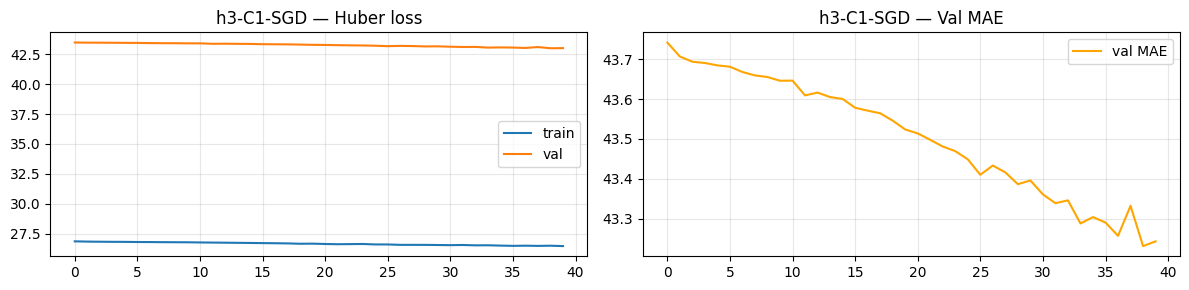

MAE=43.23083
  RMSProp ...   ep   5 | train=26.40867 val=42.85909 MAE=43.11787
  ep  10 | train=25.56477 val=41.84158 MAE=42.09576
  ep  15 | train=24.53241 val=40.97108 MAE=41.23426
  ep  20 | train=23.49604 val=39.59747 MAE=39.83793
  ep  25 | train=22.69722 val=39.26199 MAE=39.50733
  ep  30 | train=22.13668 val=38.54997 MAE=38.80079
  ep  35 | train=21.64911 val=37.93478 MAE=38.18430
  ep  40 | train=21.56558 val=37.83310 MAE=38.08298
[h3-C1-RMSProp] MAE=38.00861  RMSE=148.68016  epochs=40


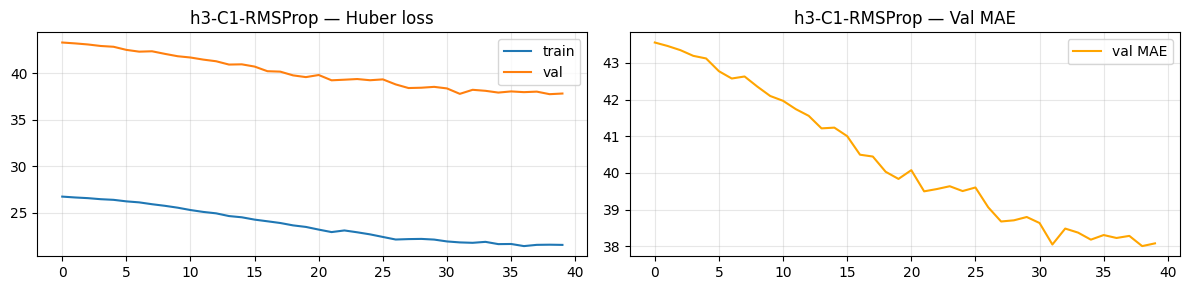

MAE=38.00861
  -> best: Adam

--- C2: Learning rate ---
  lr=0.0001 ...   ep   5 | train=26.47929 val=42.96301 MAE=43.21673
  ep  10 | train=25.90207 val=42.26081 MAE=42.52589
  ep  15 | train=24.98148 val=41.53251 MAE=41.82668
  ep  20 | train=23.99086 val=40.01260 MAE=40.28453
  ep  25 | train=23.10991 val=39.07924 MAE=39.32410
  ep  30 | train=22.28316 val=38.41777 MAE=38.66737
  ep  35 | train=21.56939 val=37.62375 MAE=37.86003
  ep  40 | train=21.23224 val=37.30449 MAE=37.55880
[h3-C2-0.0001] MAE=37.46419  RMSE=145.48901  epochs=40


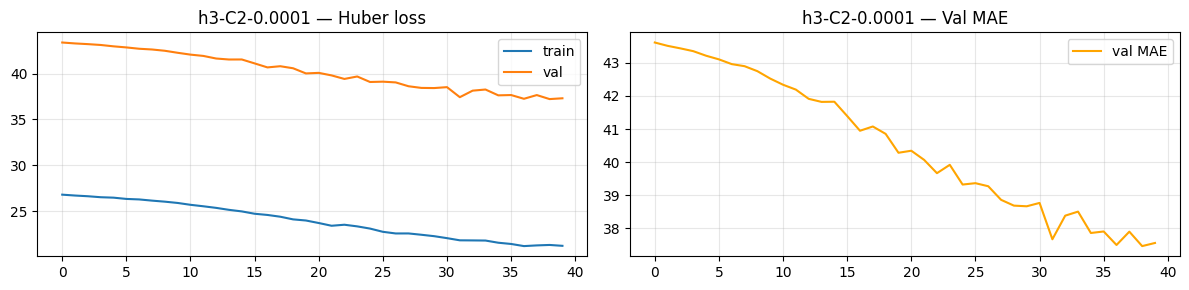

MAE=37.46419
  lr=0.001 ...   ep   5 | train=23.25763 val=41.18229 MAE=41.42289
  ep  10 | train=20.84859 val=35.21718 MAE=35.45829
  ep  15 | train=20.32030 val=34.47738 MAE=34.71082
  ep  20 | train=20.02330 val=34.65568 MAE=34.89042
  ep  25 | train=19.58662 val=33.32544 MAE=33.56265
  ep  30 | train=19.18022 val=33.86806 MAE=34.10783
  ep  35 | train=18.75272 val=33.26803 MAE=33.50591
  ep  40 | train=18.55461 val=33.22719 MAE=33.46244
[h3-C2-0.001] MAE=33.31097  RMSE=132.69106  epochs=40


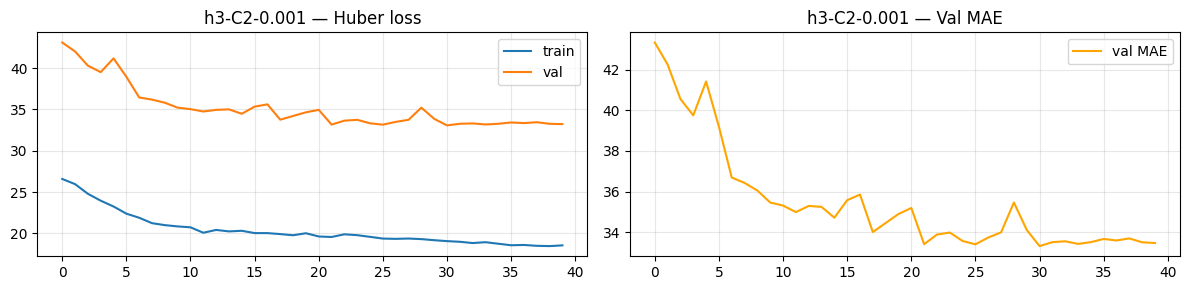

MAE=33.31097
  lr=0.005 ...   ep   5 | train=21.81056 val=36.66444 MAE=36.90730
  ep  10 | train=20.42667 val=34.08257 MAE=34.32584
  ep  15 | train=19.86863 val=34.58257 MAE=34.81969
  ep  20 | train=19.40317 val=33.89821 MAE=34.13543
  ep  25 | train=18.97091 val=34.39170 MAE=34.62776
  ep  29 | train=18.85873 val=33.99947 MAE=34.23549
  → Early stop at epoch 29
[h3-C2-0.005] MAE=33.53049  RMSE=135.84933  epochs=29


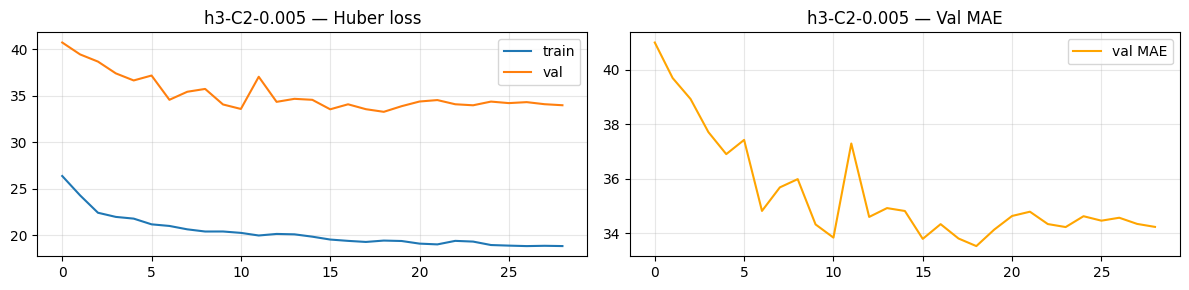

MAE=33.53049
  -> best: 0.001

--- C3: Batch size ---
  bs=32 ...   ep   5 | train=21.38596 val=37.43735 MAE=37.67649
  ep  10 | train=19.97488 val=36.09560 MAE=36.33363
  ep  15 | train=19.65479 val=34.21491 MAE=34.45692
  ep  20 | train=19.15930 val=35.41875 MAE=35.65774
  ep  25 | train=18.89328 val=36.09369 MAE=36.33238
  → Early stop at epoch 25
[h3-C3-32] MAE=34.45692  RMSE=138.95421  epochs=25


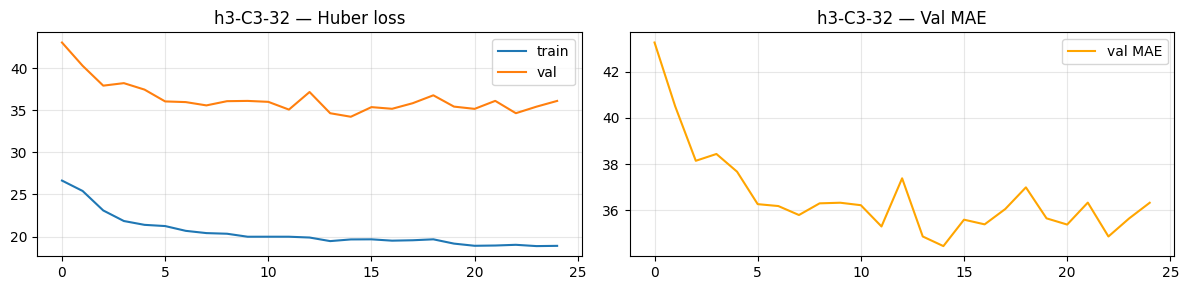

MAE=34.45692
  bs=64 ...   ep   5 | train=21.90172 val=37.32664 MAE=37.57252
  ep  10 | train=20.47425 val=34.87437 MAE=35.11250
  ep  15 | train=19.71044 val=34.11979 MAE=34.35751
  ep  20 | train=19.08096 val=34.72928 MAE=34.96870
  ep  22 | train=18.92021 val=34.30098 MAE=34.53436
  → Early stop at epoch 22
[h3-C3-64] MAE=33.69593  RMSE=134.76035  epochs=22


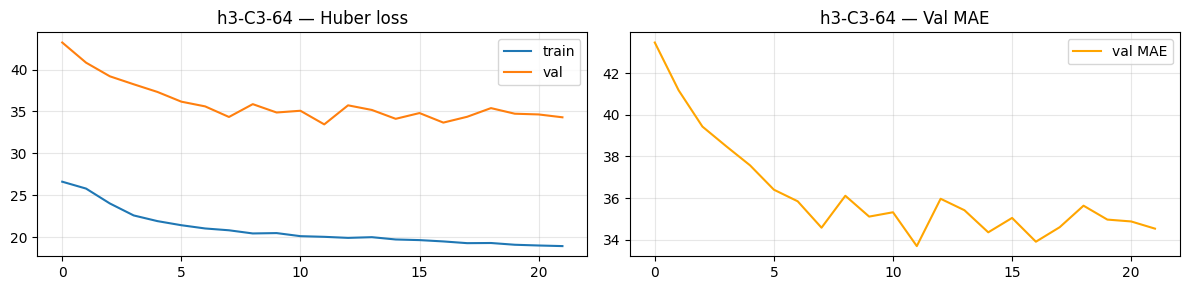

MAE=33.69593
  bs=128 ...   ep   5 | train=22.55327 val=38.50420 MAE=38.75675
  ep  10 | train=21.12196 val=35.04058 MAE=35.28174
  ep  15 | train=20.34861 val=34.54604 MAE=34.78711
  ep  20 | train=19.59512 val=33.53707 MAE=33.77726
  ep  25 | train=19.01406 val=34.02061 MAE=34.26181
  ep  30 | train=18.83901 val=34.15036 MAE=34.38961
  → Early stop at epoch 30
[h3-C3-128] MAE=33.77726  RMSE=134.66615  epochs=30


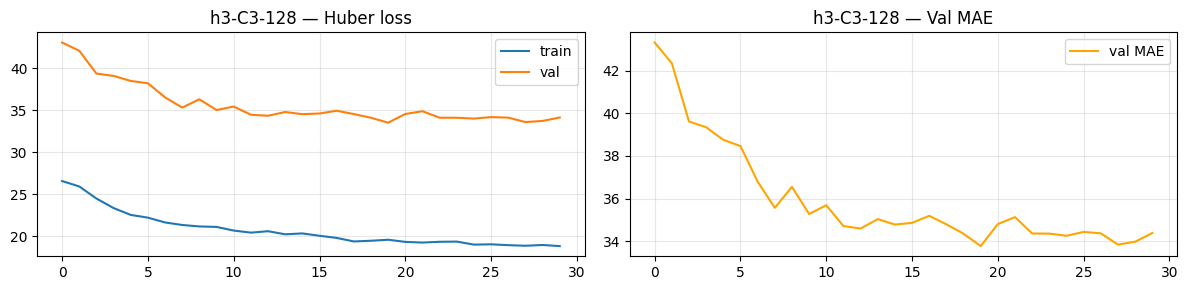

MAE=33.77726
  -> best: 64

--- C4: Scheduler ---
  ReduceOnPlateau ...   ep   5 | train=22.31523 val=38.54251 MAE=38.78275
  ep  10 | train=20.69322 val=35.48326 MAE=35.72496
  ep  15 | train=19.74609 val=35.44005 MAE=35.67909
  ep  20 | train=19.52704 val=35.43145 MAE=35.67047
  ep  25 | train=19.04257 val=34.67354 MAE=34.91249
  ep  26 | train=18.95960 val=34.79679 MAE=35.03575
  → Early stop at epoch 26
[h3-C4-ReduceOnPlateau] MAE=34.56728  RMSE=136.01154  epochs=26


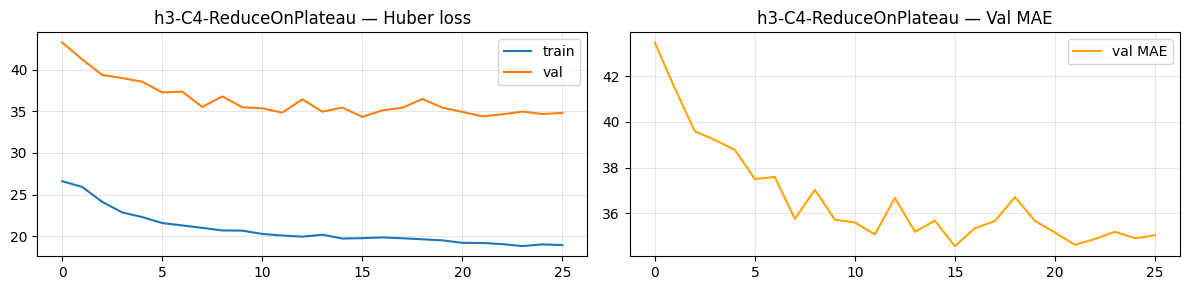

MAE=34.56728
  CosineAnnealing ...   ep   5 | train=22.13484 val=38.46940 MAE=38.70631
  ep  10 | train=20.48845 val=35.21495 MAE=35.45390
  ep  15 | train=19.56089 val=35.03728 MAE=35.27413
  ep  20 | train=19.23298 val=34.74886 MAE=34.98802
  ep  25 | train=19.17188 val=34.42632 MAE=34.66570
  ep  30 | train=18.61192 val=34.98485 MAE=35.22432
  ep  35 | train=18.44519 val=33.73055 MAE=33.96968
  ep  37 | train=18.61964 val=34.16144 MAE=34.40118
  → Early stop at epoch 37
[h3-C4-CosineAnnealing] MAE=33.82126  RMSE=134.64026  epochs=37


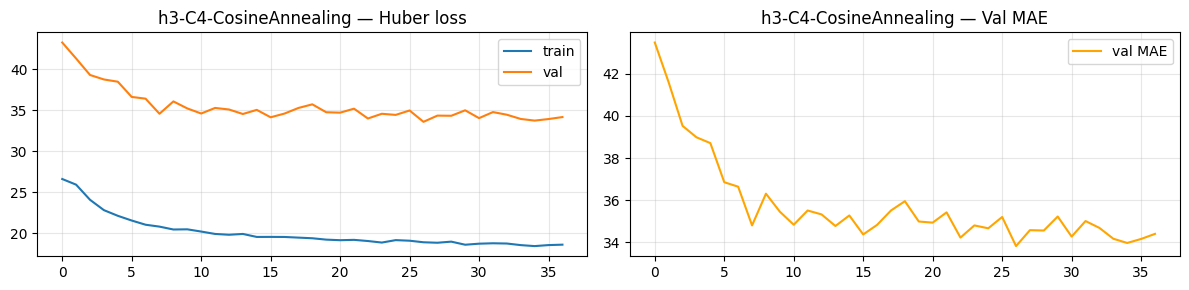

MAE=33.82126
  None ...   ep   5 | train=22.36188 val=38.35619 MAE=38.59451
  ep  10 | train=20.61339 val=33.98781 MAE=34.22867
  ep  15 | train=19.55840 val=34.08999 MAE=34.32685
  ep  20 | train=19.49197 val=35.23752 MAE=35.47530
  ep  25 | train=19.33556 val=34.36687 MAE=34.60597
  ep  26 | train=19.27992 val=34.37054 MAE=34.61269
  → Early stop at epoch 26
[h3-C4-None] MAE=33.79954  RMSE=133.67001  epochs=26


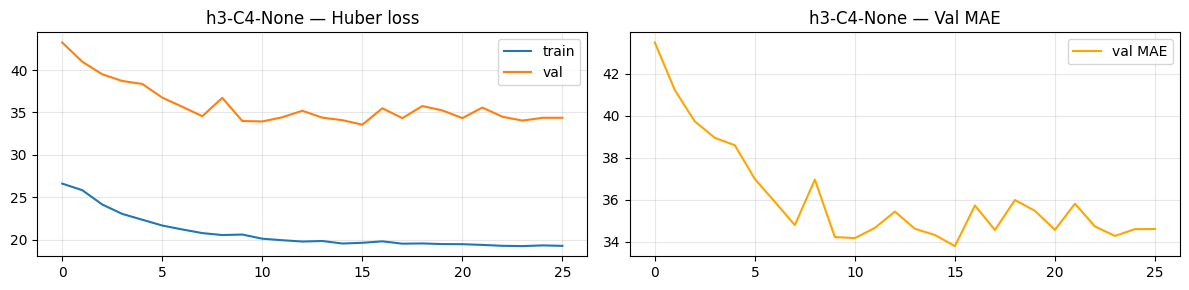

MAE=33.79954
  -> best: None

--- C5: Patience ---
  patience=4 ...   ep   5 | train=22.33267 val=37.96028 MAE=38.20030
  ep  10 | train=20.81763 val=35.10966 MAE=35.35180
  ep  15 | train=19.60353 val=34.65744 MAE=34.89771
  ep  16 | train=19.82742 val=34.28709 MAE=34.52719
  → Early stop at epoch 16
[h3-C5-4] MAE=34.15229  RMSE=134.04704  epochs=16


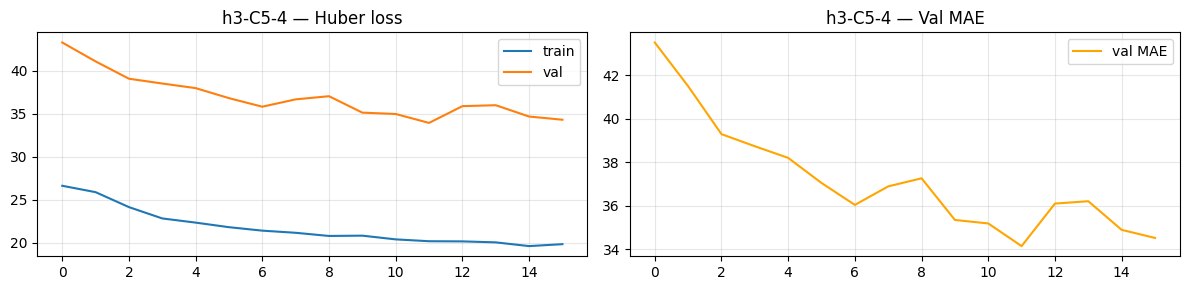

MAE=34.15229
  patience=6 ...   ep   5 | train=22.16140 val=38.37965 MAE=38.62317
  ep  10 | train=20.89843 val=35.14333 MAE=35.38477
  ep  15 | train=19.75287 val=34.30428 MAE=34.54264
  ep  20 | train=19.48187 val=35.42383 MAE=35.65946
  ep  22 | train=19.54976 val=35.26425 MAE=35.50199
  → Early stop at epoch 22
[h3-C5-6] MAE=34.25406  RMSE=134.75900  epochs=22


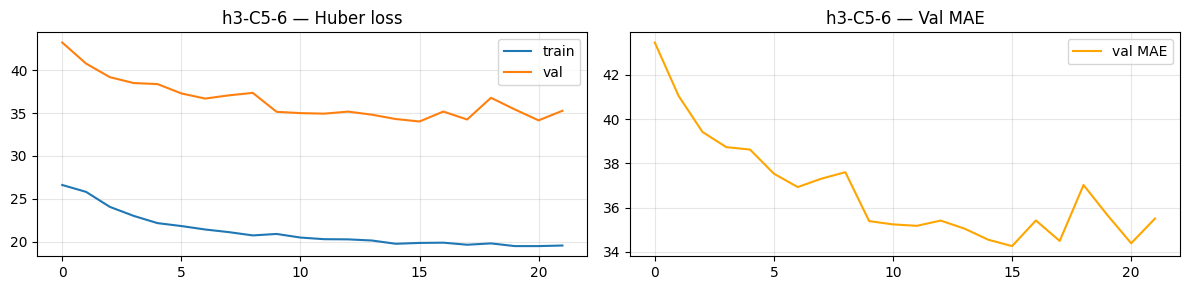

MAE=34.25406
  patience=10 ...   ep   5 | train=22.10719 val=38.23448 MAE=38.47135
  ep  10 | train=20.61512 val=33.99986 MAE=34.23924
  ep  15 | train=19.61092 val=34.25432 MAE=34.49211
  ep  20 | train=19.45817 val=34.73043 MAE=34.96966
  ep  25 | train=19.31429 val=33.62248 MAE=33.86134
  ep  28 | train=19.21622 val=35.05122 MAE=35.29085
  → Early stop at epoch 28
[h3-C5-10] MAE=33.56572  RMSE=132.39072  epochs=28


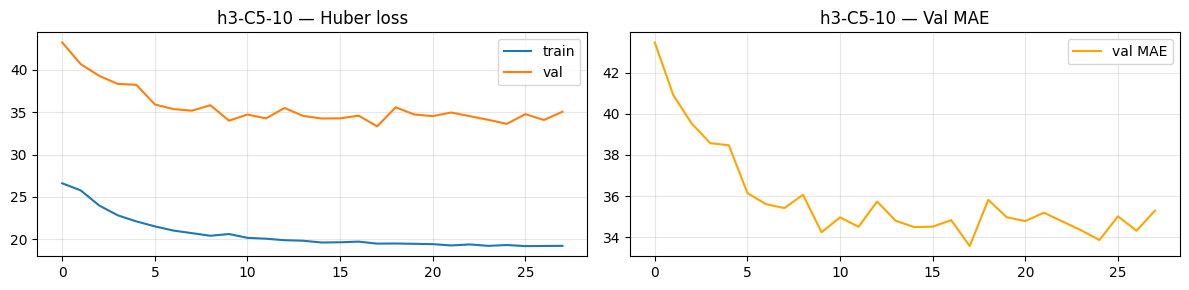

MAE=33.56572
  -> best: 10

--- D1: Num layers ---
  layers=1 ...   ep   5 | train=24.67830 val=39.20460 MAE=39.44778
  ep  10 | train=21.89487 val=37.05967 MAE=37.29725
  ep  15 | train=21.11341 val=36.73821 MAE=36.97515
  ep  20 | train=20.81278 val=35.76053 MAE=35.99733
  ep  25 | train=20.06215 val=35.35777 MAE=35.59602
  ep  30 | train=20.14820 val=35.14682 MAE=35.38348
  ep  35 | train=19.93090 val=34.76707 MAE=35.00261
  ep  40 | train=19.91735 val=34.82666 MAE=35.06634
[h3-D1-1] MAE=34.85289  RMSE=136.22839  epochs=40


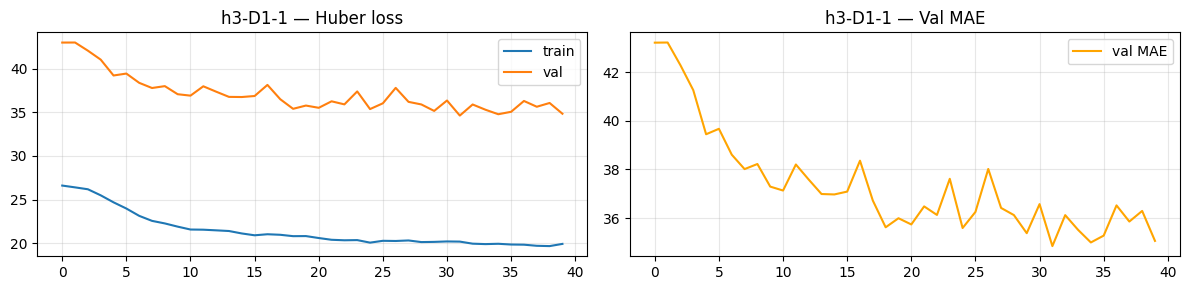

MAE=34.85289
  layers=2 ...   ep   5 | train=22.86118 val=39.88277 MAE=40.12319
  ep  10 | train=20.91761 val=36.31601 MAE=36.55473
  ep  15 | train=19.95184 val=34.05812 MAE=34.29333
  ep  20 | train=19.70447 val=34.44059 MAE=34.67833
  ep  25 | train=19.68272 val=34.52609 MAE=34.76151
  ep  30 | train=19.42832 val=34.59823 MAE=34.83379
  ep  35 | train=19.31599 val=35.12085 MAE=35.35759
  ep  37 | train=19.25364 val=34.92898 MAE=35.16622
  → Early stop at epoch 37
[h3-D1-2] MAE=33.88726  RMSE=134.88722  epochs=37


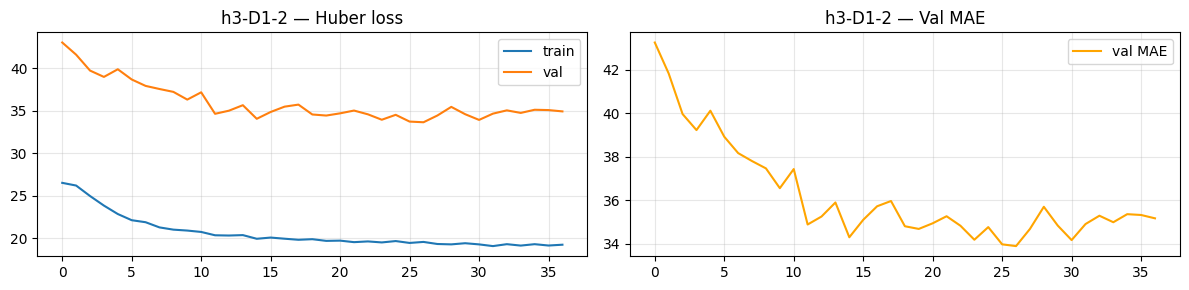

MAE=33.88726
  layers=3 ...   ep   5 | train=22.40195 val=38.73219 MAE=38.97146
  ep  10 | train=20.62350 val=35.28824 MAE=35.52811
  ep  15 | train=19.64907 val=34.74871 MAE=34.98774
  ep  20 | train=19.51833 val=35.00405 MAE=35.24450
  ep  25 | train=19.34493 val=34.45580 MAE=34.69461
  ep  26 | train=19.48526 val=34.62282 MAE=34.86510
  → Early stop at epoch 26
[h3-D1-3] MAE=34.25336  RMSE=134.50597  epochs=26


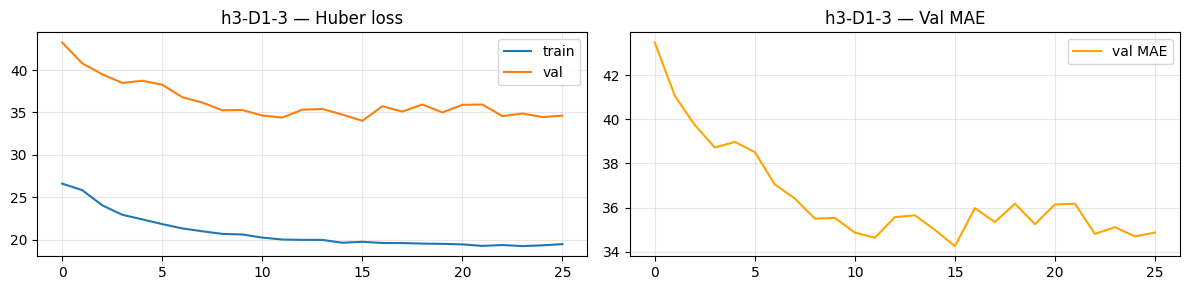

MAE=34.25336
  -> best: 2

--- D2: Num filters ---
  filters=64 ...   ep   5 | train=22.96518 val=40.58372 MAE=40.82195
  ep  10 | train=20.84060 val=36.08427 MAE=36.32329
  ep  15 | train=19.92301 val=34.55858 MAE=34.79479
  ep  20 | train=19.56562 val=35.09989 MAE=35.33831
  ep  25 | train=19.59959 val=34.93876 MAE=35.17585
  → Early stop at epoch 25
[h3-D2-64] MAE=34.79479  RMSE=136.13373  epochs=25


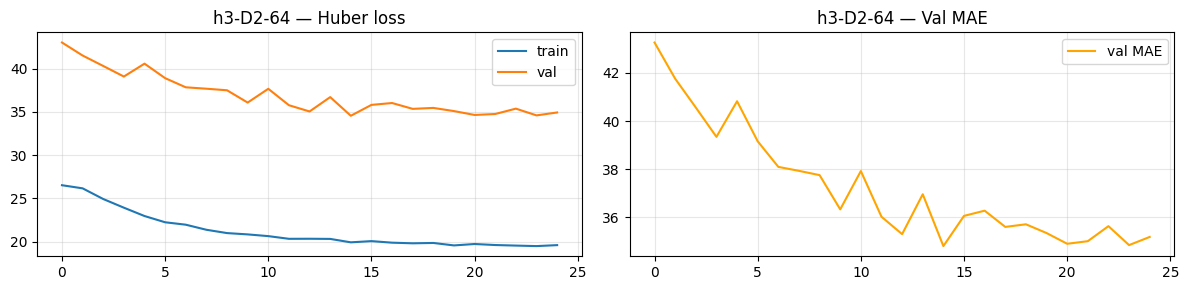

MAE=34.79479
  filters=128 ...   ep   5 | train=21.27299 val=35.91599 MAE=36.15934
  ep  10 | train=19.63162 val=35.84134 MAE=36.07978
  ep  15 | train=19.51077 val=35.02032 MAE=35.25746
  ep  17 | train=19.18194 val=33.99327 MAE=34.23011
  → Early stop at epoch 17
[h3-D2-128] MAE=33.88442  RMSE=131.59225  epochs=17


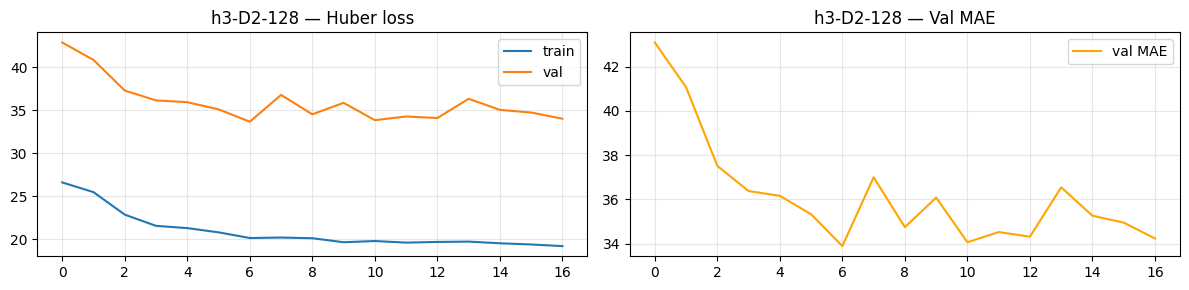

MAE=33.88442
  filters=256 ...   ep   5 | train=20.47940 val=35.88632 MAE=36.12803
  ep  10 | train=19.43926 val=34.68670 MAE=34.92386
  ep  15 | train=19.29254 val=33.99149 MAE=34.22869
  ep  19 | train=19.00674 val=34.12858 MAE=34.36630
  → Early stop at epoch 19
[h3-D2-256] MAE=33.78206  RMSE=134.57457  epochs=19


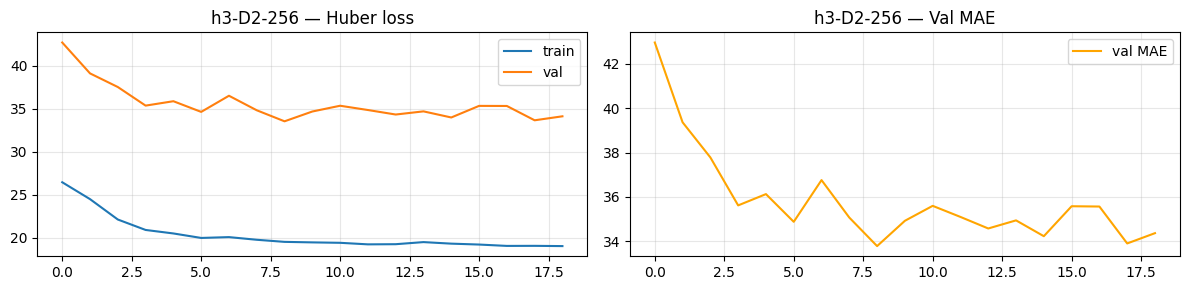

MAE=33.78206
  -> best: 256

--- D3: Dropout ---
  dropout=0.0 ... 

In [ ]:
# ── Run experiments for all 4 horizons ───────────────────────────────────────
best_configs  = {}   # {hz: cfg dict}
exp_scalers   = {}   # {hz: RobustScaler}  (from experiment data sample)
exp_feat_cols = {}   # {hz: list of feature column names}

for _hz, _path in HORIZONS.items():
    best_configs[_hz], exp_scalers[_hz], exp_feat_cols[_hz] = \
        run_experiments_for_horizon(_hz, _path)

print("\n\n=== All horizons done ===")
show_log()
pd.DataFrame(results_log).to_csv("experiment_log.csv", index=False)
print("Saved experiment_log.csv")


<a name="3"></a>
## 3 - Best Config per Horizon


In [ ]:
print("== Best configuration per horizon ==")
print(f"{'Horizon':>8} | {'Optimizer':>10} | {'LR':>7} | {'BS':>4} | "
      f"{'Scheduler':>18} | {'Pat':>3} | {'Layers':>6} | {'Filters':>7} | {'Drop':>5}")
print("-" * 90)
for hz, cfg in best_configs.items():
    print(f"{hz:>8} | {cfg['optimizer']:>10} | {cfg['lr']:>7} | {cfg['batch_size']:>4} | "
          f"{cfg['scheduler']:>18} | {cfg['patience']:>3} | {cfg['num_layers']:>6} | "
          f"{cfg['num_filters']:>7} | {cfg['dropout']:>5}")


<a name="4"></a>
## 4 - Final Training (Full Dataset, Best Config per Horizon)


In [ ]:
# ── E: Final training — one model per horizon, full dataset ──────────────────
import gc, time

final_models    = {}   # {hz: trained CNNForecaster}
final_scalers   = {}   # {hz: RobustScaler fit on all train data}
final_feat_cols = {}   # {hz: feature column names}

_t0_total = time.perf_counter()

for _hz, _fs_path in HORIZONS.items():
    _cfg = best_configs[_hz]
    print(f"\n{'='*60}")
    print(f"  FINAL TRAINING  |  horizon={_hz}")
    print(f"{'='*60}")
    _t1 = time.perf_counter()

    # Load ALL groups (no sampling)
    _X_tr, _y_tr, _X_va, _y_va, _input_size, _scaler, _feat_cols = \
        load_feature_set_for_horizon(_hz, _fs_path, n_sample=999_999)

    _tr_dl = DataLoader(TSDataset(_X_tr, _y_tr), batch_size=_cfg["batch_size"],
                        shuffle=True, num_workers=0)
    _va_dl = DataLoader(TSDataset(_X_va, _y_va), batch_size=_cfg["batch_size"] * 2,
                        num_workers=0)
    del _X_tr, _y_tr, _X_va, _y_va; gc.collect()

    _model = CNNForecaster(
        input_size  = _input_size,
        num_filters = _cfg["num_filters"],
        kernel_size = BEST_A_KERNEL_SIZE,
        num_layers  = _cfg["num_layers"],
        dropout     = _cfg["dropout"],
    ).to(DEVICE)
    torch.manual_seed(SEED)

    _save_path = f"best_final_h{_hz}.pt"
    _mae, _rmse, _ep, _hist = train_and_eval(
        _model, _tr_dl, _va_dl,
        optimizer_name = _cfg["optimizer"],
        lr             = _cfg["lr"],
        scheduler_name = _cfg["scheduler"],
        patience       = _cfg["patience"],
        save_path      = _save_path,
    )

    # Reload best weights, store
    _model.load_state_dict(torch.load(_save_path, map_location=DEVICE, weights_only=True))
    _model.eval()
    final_models[_hz]    = _model
    final_scalers[_hz]   = _scaler
    final_feat_cols[_hz] = _feat_cols

    print(f"\nSaved {_save_path}  |  MAE={_mae:.5f}  RMSE={_rmse:.5f}  "
          f"epochs={_ep}  [{time.perf_counter()-_t1:.1f}s]")
    plot_history(_hist, f"Final model h{_hz}")
    gc.collect()

print(f"\nAll 4 models trained in {(time.perf_counter()-_t0_total)/60:.1f} min")


<a name="5"></a>
## 5 - Inference on Test → submission.csv


In [ ]:
# ── E2: Inference on test → submission.csv ───────────────────────────────────
# For each horizon: load {folder}/test.parquet, build sequences, batch forward pass.
# Merge predictions by id onto the ORIGINAL test.parquet row order (unchanged).
import gc, time

_t0_inf = time.perf_counter()
print("Running inference …")

# Load original test to fix submission row order
df_test_orig = pd.read_parquet(TEST_PATH_ORIG, columns=["id", "horizon"])
print(f"Original test rows: {len(df_test_orig):,}")

preds_frames = []

for _hz, _folder in HORIZONS.items():
    print(f"\nHorizon {_hz} …", end=" ", flush=True)
    _model     = final_models[_hz]
    _scaler    = final_scalers[_hz]
    _feat_cols = final_feat_cols[_hz]
    _n_feats   = len(_feat_cols)
    _input_sz  = 1 + _n_feats

    # Load preprocessed test for this horizon
    df_h = pd.read_parquet(f"{_folder}/test.parquet")

    _missing = [c for c in _feat_cols if c not in df_h.columns]
    if _missing:
        raise KeyError(f"h{_hz}: missing columns: {_missing}")

    ids_h, preds_h = [], []

    for _gkey, _gdf in df_h.groupby(GROUP_KEYS, sort=False):
        _gdf   = _gdf.sort_values(TIME_COL)
        _ids   = _gdf[ID_COL].values
        T_test = len(_ids)

        # Build input matrix: y_target placeholder = 0, then features
        _feats  = (_gdf[_feat_cols]
                      .ffill().bfill().fillna(0.0)
                      .values.astype(np.float32))
        _y_ph   = np.zeros((T_test, 1), dtype=np.float32)
        _data   = np.hstack([_y_ph, _feats])          # (T_test, input_sz)

        # Scale using the scaler fit on training data
        _data_sc = _scaler.transform(_data).astype(np.float32)

        # Pad rows if group is shorter than SEQ_LEN
        if T_test < SEQ_LEN:
            _pad     = np.zeros((SEQ_LEN - T_test, _input_sz), dtype=np.float32)
            _data_sc = np.vstack([_pad, _data_sc])

        T_pad = len(_data_sc)

        # Build all SEQ_LEN windows for this group as one batch
        # Each row i gets window ending at position (T_pad - T_test + i + SEQ_LEN)
        _windows = np.stack(
            [_data_sc[T_pad - T_test + i : T_pad - T_test + i + SEQ_LEN].T
             for i in range(T_test)],
            axis=0,
        ).astype(np.float32)                           # (T_test, input_sz, SEQ_LEN)

        _model.eval()
        with torch.no_grad():
            _xt      = torch.tensor(_windows, dtype=torch.float32).to(DEVICE)
            _preds_s = _model(_xt).cpu().numpy()       # (T_test,) — scaled predictions

        # Inverse-transform: RobustScaler is per-column → use dummy row with zeros
        _dummy       = np.zeros((T_test, _input_sz), dtype=np.float32)
        _dummy[:, 0] = _preds_s
        _preds_real  = _scaler.inverse_transform(_dummy)[:, 0]

        ids_h.extend(_ids.tolist())
        preds_h.extend(_preds_real.tolist())

    preds_frames.append(pd.DataFrame({"id": ids_h, "y_target": preds_h}))
    print(f"{len(ids_h):,} rows predicted")
    gc.collect()

# Combine and align to ORIGINAL test.parquet row order
all_preds  = pd.concat(preds_frames, ignore_index=True)

# Sanity: check coverage
n_missing = all_preds["y_target"].isna().sum()
if len(all_preds) != len(df_test_orig):
    print(f"WARNING: predicted {len(all_preds)} rows, expected {len(df_test_orig)}")

submission = df_test_orig[["id"]].merge(all_preds, on="id", how="left")

if submission["y_target"].isna().any():
    n_nan = submission["y_target"].isna().sum()
    print(f"WARNING: {n_nan} NaN predictions after merge — check horizon coverage")

submission.to_csv("submission.csv", index=False)
print(f"\nSaved submission.csv  |  {len(submission):,} rows  "
      f"|  {time.perf_counter()-_t0_inf:.1f}s")
print(f"Preview (first 10):\n{submission.head(10).to_string(index=False)}")
print(f"\nStats: mean={submission.y_target.mean():.4f}  "
      f"std={submission.y_target.std():.4f}  "
      f"min={submission.y_target.min():.4f}  "
      f"max={submission.y_target.max():.4f}")

# Verify row order matches original test.parquet exactly
assert list(submission["id"]) == list(df_test_orig["id"]), \
    "ERROR: submission row order does not match original test.parquet!"
print("\nRow order verified: matches original test.parquet exactly.")
